In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('housing_price.csv')
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,size,Price
0,4996.320951,2.617057,4,6825.704497,184.022626,2.072153e+06
1,9605.714451,2.469788,7,2637.720585,155.151113,2.630257e+06
2,7855.951534,9.062546,7,7464.914286,160.286422,2.502930e+06
3,6789.267874,2.495462,5,9460.533670,95.154017,1.925008e+06
4,3248.149124,2.719497,9,6605.322024,193.493180,2.289755e+06


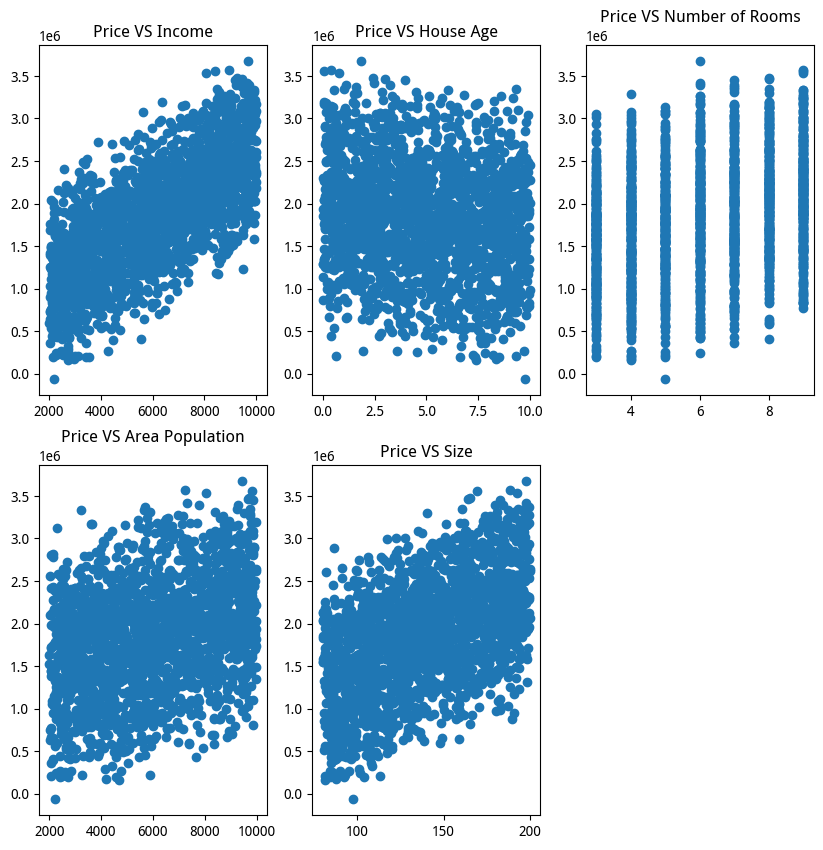

In [15]:
%matplotlib inline
from matplotlib import pyplot as plt
fig=plt.figure(figsize=(10,10))
fig1=plt.subplot(231)
plt.scatter(data.loc[:,'Avg. Area Income'],data.loc[:,'Price'])
plt.title('Price VS Income')

fig1=plt.subplot(232)
plt.scatter(data.loc[:,'Avg. Area House Age'],data.loc[:,'Price'])
plt.title('Price VS House Age')

fig1=plt.subplot(233)
plt.scatter(data.loc[:,'Avg. Area Number of Rooms'],data.loc[:,'Price'])
plt.title('Price VS Number of Rooms')

fig1=plt.subplot(234)
plt.scatter(data.loc[:,'Area Population'],data.loc[:,'Price'])
plt.title('Price VS Area Population')

fig1=plt.subplot(235)
plt.scatter(data.loc[:,'size'],data.loc[:,'Price'])
plt.title('Price VS Size')

plt.show()

In [3]:
X=data.loc[:,'size']
y=data.loc[:,'Price']
y.head()

0    2.072153e+06
1    2.630257e+06
2    2.502930e+06
3    1.925008e+06
4    2.289755e+06
Name: Price, dtype: float64

In [4]:
X=np.array(X)
X=X.reshape(-1,1)
print(X.shape)

(2000, 1)


In [5]:
from sklearn.linear_model import LinearRegression
LR1=LinearRegression()
LR1.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_predict_1=LR1.predict(X)
print(y_predict_1)
from sklearn.metrics import mean_squared_error,r2_score
mean_squared_error_1=mean_squared_error(y,y_predict_1)
r2_score_1=r2_score(y,y_predict_1)
print(mean_squared_error_1,r2_score_1)

[2286243.25946748 1997950.25666641 2049228.26337235 ... 1569335.2807354
 2178103.55148475 1909235.76046768]
327962922197.99835 0.25917650732489483


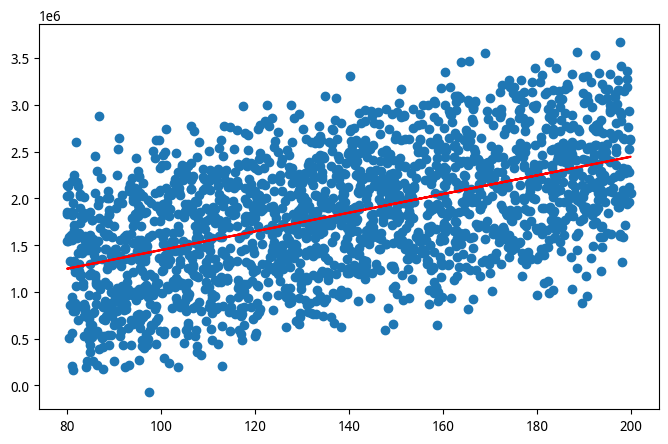

In [7]:
fig6=plt.figure(figsize=(8,5))
plt.scatter(X,y)
plt.plot(X,y_predict_1,'r')
plt.show()

In [8]:
X_multi=data.drop(['Price'],axis=1)
X_multi

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,size
0,4996.320951,2.617057,4,6825.704497,184.022626
1,9605.714451,2.469788,7,2637.720585,155.151113
2,7855.951534,9.062546,7,7464.914286,160.286422
3,6789.267874,2.495462,5,9460.533670,95.154017
4,3248.149124,2.719497,9,6605.322024,193.493180
...,...,...,...,...,...
1995,7255.641250,4.421070,6,5686.949882,169.535717
1996,9652.916969,3.344012,6,7370.435389,142.497870
1997,2551.664131,3.945723,4,3297.466979,112.226857
1998,2456.437769,5.299406,7,5891.539097,173.192821


In [9]:
LR_multi=LinearRegression()
LR_multi.fit(X_multi,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_predict_multi=LR_multi.predict(X_multi)
print(y_predict_multi)

[2091036.3364187  2612521.4597617  2468287.2074701  ...  464184.57302104
 1547431.95065353 2025370.12110702]


In [11]:
mean_squared_error_multi=mean_squared_error(y,y_predict_multi)
r2_score_multi=r2_score(y,y_predict_multi)
print(mean_squared_error_multi,r2_score_multi)

232616185.8044243 0.9994745517753487


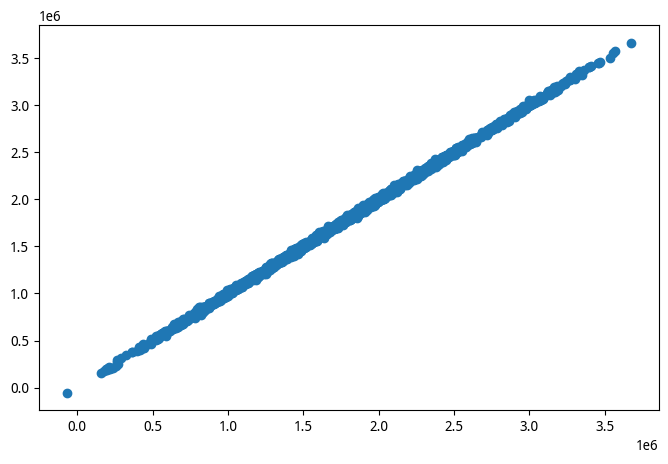

In [12]:
fig7=plt.figure(figsize=(8,5))
plt.scatter(y,y_predict_multi)
plt.show()

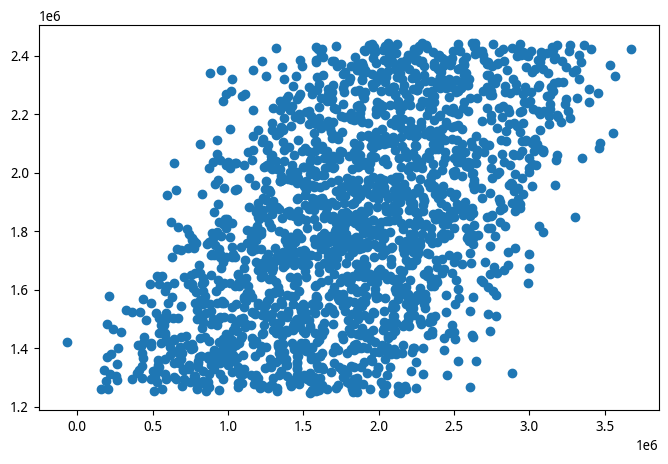

In [13]:
fig8=plt.figure(figsize=(8,5))
plt.scatter(y,y_predict_1)
plt.show()

In [14]:
X_test_np=np.array([
    [65000,5,5,30000,200]
])
feature_names = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'size']
X_test_df = pd.DataFrame(X_test_np, columns=feature_names)
print(X_test_df)
y_test_predict=LR_multi.predict(X_test_df)
print(y_test_predict)

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             65000                    5                          5   

   Area Population  size  
0            30000   200  
[16560551.18790791]
